<a href="https://colab.research.google.com/github/binittababu20-cmd/data-science/blob/main/pg11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment:
Wine Quality Analysis and Naïve Bayes Classification
Using the Wine_Quality.csv dataset:

1.	Perform basic EDA by displaying the first five records, missing values, descriptive statistics, and quality distribution.
2.	Plot a scatter plot of alcohol vs pH, a histogram of alcohol, and a box plot of alcohol by quality.
3.	Apply Gaussian Naïve Bayes to predict quality using the numerical features, with an 80:20 train-test split.
4.	Display the classification report and accuracy.



### Task 1: Basic Exploratory Data Analysis (EDA)
Perform basic EDA by displaying the first five records, missing values, descriptive statistics, and quality distribution.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/WineQT.csv')

print('First five records:')
display(df.head())

First five records:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
print('\nMissing values:')
display(df.isnull().sum())


Missing values:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [3]:
print('\nDescriptive statistics:')
display(df.describe())


Descriptive statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [4]:
print('\nQuality distribution:')
display(df['quality'].value_counts())


Quality distribution:


,count
quality,
5,483
6,462
7,143
4,33
8,16
3,6


### Task 2: Data Visualization
Plot a scatter plot of alcohol vs pH, a histogram of alcohol, and a box plot of alcohol by quality.

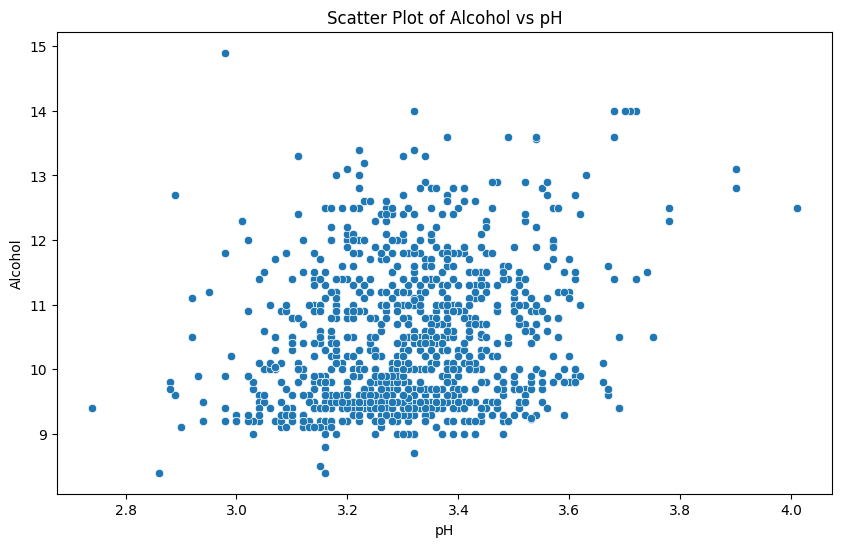

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of alcohol vs pH
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pH', y='alcohol', data=df)
plt.title('Scatter Plot of Alcohol vs pH')
plt.xlabel('pH')
plt.ylabel('Alcohol')
plt.show()

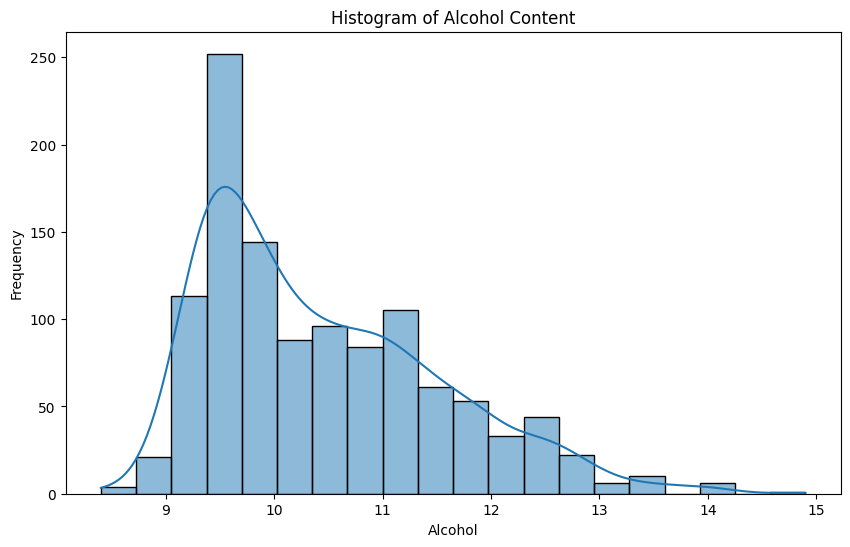

In [6]:
# Histogram of alcohol
plt.figure(figsize=(10, 6))
sns.histplot(df['alcohol'], kde=True, bins=20)
plt.title('Histogram of Alcohol Content')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.show()

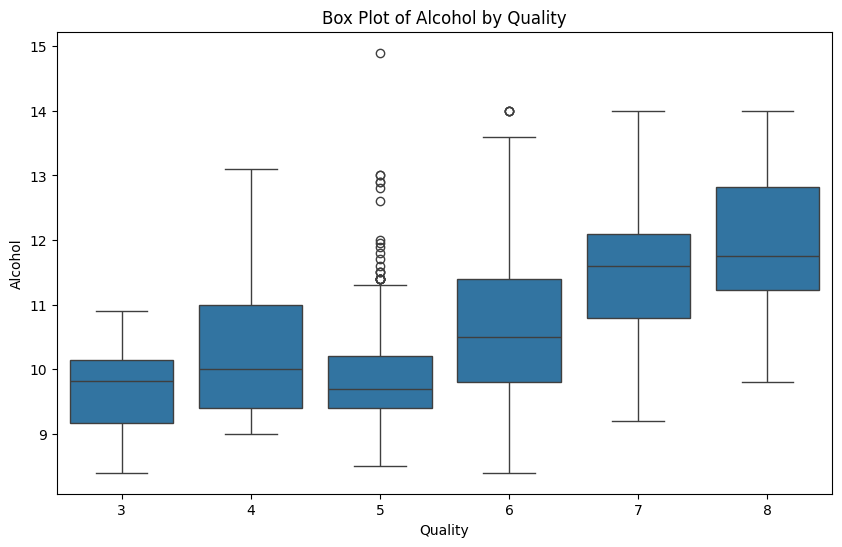

In [7]:
# Box plot of alcohol by quality
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Box Plot of Alcohol by Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

### Task 3: Gaussian Naïve Bayes Classification
Apply Gaussian Naïve Bayes to predict quality using the numerical features, with an 80:20 train-test split.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Prepare the data
# Drop the 'Id' column as it's not a feature for prediction
X = df.drop(['quality', 'Id'], axis=1)
y = df['quality']

# Split the data into training and testing sets (80:20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (914, 11)
Shape of X_test: (229, 11)
Shape of y_train: (914,)
Shape of y_test: (229,)


### Task 4: Model Evaluation
Display the classification report and accuracy.

In [9]:
# Initialize and train the Gaussian Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Display the classification report and accuracy
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nAccuracy Score:')
print(accuracy_score(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         6
           5       0.74      0.52      0.61        96
           6       0.57      0.69      0.62        99
           7       0.50      0.58      0.54        26
           8       0.00      0.00      0.00         2

    accuracy                           0.58       229
   macro avg       0.30      0.30      0.29       229
weighted avg       0.61      0.58      0.59       229


Accuracy Score:
0.5807860262008734


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
